# Credit Card Fraud Detection

## Problem Statement

The objective of this project is to build a machine learning model capable of identifying fraudulent credit card transactions using historical transaction data.

---

## Workflow

1. Import Libraries
2. Load Dataset
3. Understand the Dataset
4. Data Cleaning
5. Exploratory Data Analysis
6. Feature Engineering
7. Model Building
8. Model Evaluation
9. Conclusion

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("data/creditcard.csv")

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [8]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

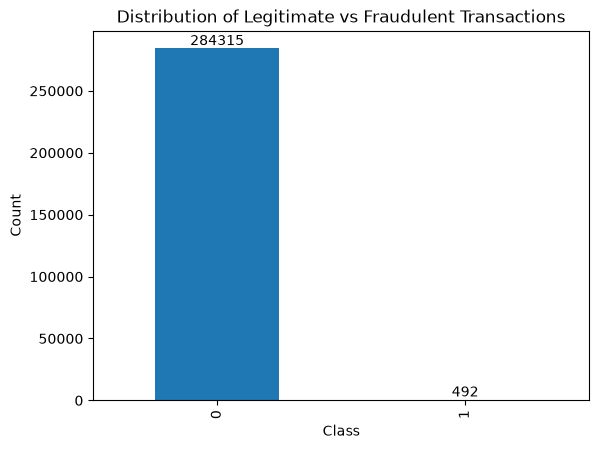

In [11]:
ax = df['Class'].value_counts().plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Legitimate vs Fraudulent Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

The dataset is highly imbalanced. Legitimate transactions (Class 0) account for 284,315 observations, while fraudulent transactions (Class 1) account for only 492 observations. The bar chart visually confirms this extreme class imbalance, indicating that fraud represents a very small fraction of all transactions.

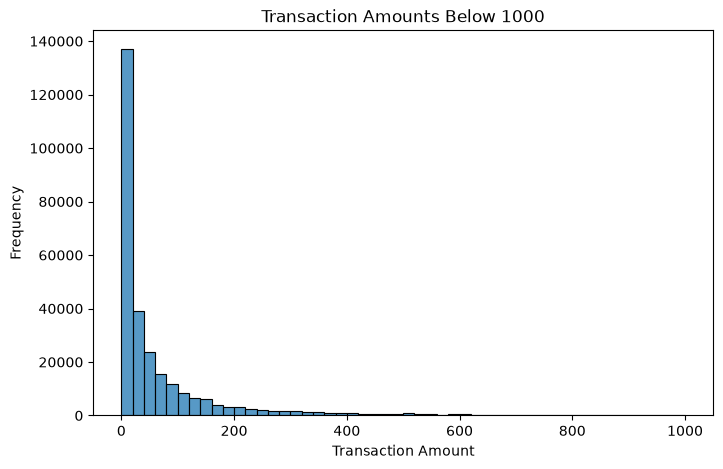

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df[df['Amount'] < 1000]['Amount'], bins=50)

plt.title("Transaction Amounts Below 1000")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

In [13]:
fraud = df[df['Class'] == 1]
legitimate = df[df['Class'] == 0]

In [14]:
fraud['Amount'].describe()

count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [15]:
legitimate['Amount'].describe()

count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

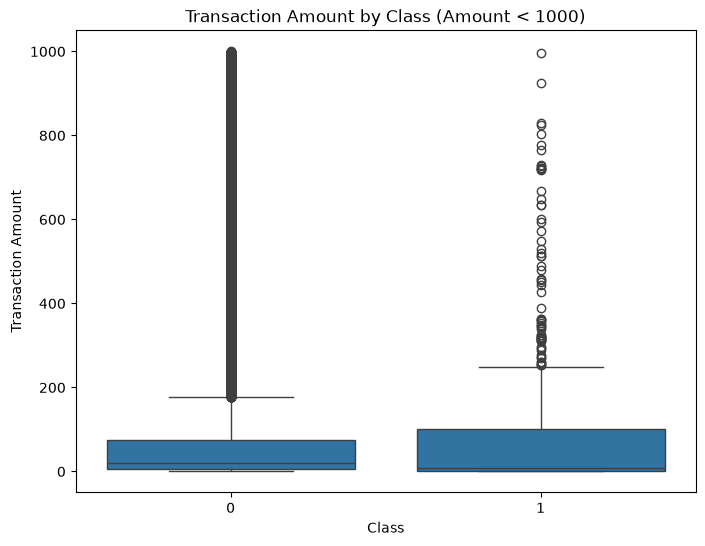

In [16]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x='Class',
    y='Amount',
    data=df[df['Amount'] < 1000]
)

plt.title("Transaction Amount by Class (Amount < 1000)")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")

plt.show()
#BOXPLOT 

### Interpretation of Box Plot (Transaction Amount < ₹1000)

- The median transaction amount for **legitimate transactions (Class 0)** is higher than that of **fraudulent transactions (Class 1)**, indicating that typical legitimate transactions tend to have slightly higher amounts.

- The box for **fraudulent transactions** is wider, suggesting greater variability in the middle 50% of fraud transaction amounts.

- Both classes contain several outliers, indicating the presence of unusually high-value transactions.

- Most transaction amounts for both legitimate and fraudulent classes are concentrated at lower values.

- The visualization confirms the observations obtained from the descriptive statistics, where fraudulent transactions had a lower median amount but still contained some relatively high-value transactions.

    Data preprocessing

In [17]:
X = df.drop('Class', axis=1)
y = df['Class']

Train-Test split : 80% data is for Training and rest 20% for testing so that we have some data to generalize 

In [18]:
from sklearn.model_selection import train_test_split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(227845, 30)
(56962, 30)
(227845,)
(56962,)


In [21]:
train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

[            Time        V1        V2        V3        V4        V5        V6  \
 265518  161919.0  1.946747 -0.752526 -1.355130 -0.661630  1.502822  4.024933   
 180305  124477.0  2.035149 -0.048880 -3.058693  0.247945  2.943487  3.298697   
 42664    41191.0 -0.991920  0.603193  0.711976 -0.992425 -0.825838  1.956261   
 198723  132624.0  2.285718 -1.500239 -0.747565 -1.668119 -1.394143 -0.350339   
 82325    59359.0 -0.448747 -1.011440  0.115903 -3.454854  0.715771 -0.147490   
 ...          ...       ...       ...       ...       ...       ...       ...   
 233802  147710.0  1.993864 -0.516866 -0.620118  0.129845 -0.285128  0.395044   
 85418    60764.0 -1.497933  0.657921  1.581568 -0.024286  0.584698  1.303031   
 29062    35301.0  1.069777  0.072105  0.496540  1.505318 -0.380277 -0.370243   
 13766    24413.0  1.280465  0.300586  0.333044  0.512720  0.065052 -0.145844   
 17677    28847.0 -0.598120  0.775041  1.823394  0.312991 -0.096171 -0.391452   
 
               V7        V

Logistic Regression 

In [22]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [23]:
model.fit(X_train, y_train)

c:\Users\naiky\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [24]:
y_pred = model.predict(X_test)

In [25]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9986482216214319
Precision: 0.6179775280898876
Recall   : 0.5612244897959183
F1 Score : 0.5882352941176471


In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.62      0.56      0.59        98

    accuracy                           1.00     56962
   macro avg       0.81      0.78      0.79     56962
weighted avg       1.00      1.00      1.00     56962



In [28]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[56830    34]
 [   43    55]]


## Interpretation of Confusion Matrix

- True Negatives (TN): 56,830 legitimate transactions were correctly classified as legitimate.

- False Positives (FP): 34 legitimate transactions were incorrectly classified as fraud.

- False Negatives (FN): 43 fraudulent transactions were incorrectly classified as legitimate.

- True Positives (TP): 55 fraudulent transactions were correctly identified as fraud.

The model performs extremely well in identifying legitimate transactions but misses some fraudulent transactions. In fraud detection, reducing False Negatives is particularly important because undetected fraud can lead to financial losses.

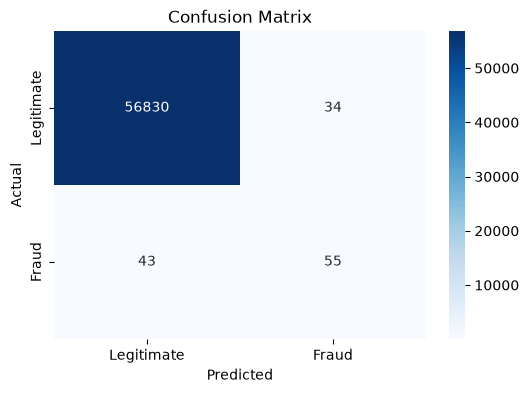

In [29]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Legitimate','Fraud'],
    yticklabels=['Legitimate','Fraud']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Logistic Regression Model Evaluation

The Logistic Regression model was trained using the training dataset and evaluated on the test dataset.

The following evaluation metrics were calculated:

- Accuracy
- Precision
- Recall
- F1 Score

A confusion matrix was also plotted to visualize the number of correct and incorrect predictions made by the model.

## Interpretation of Classification Report

- The model achieved nearly 100% accuracy on the test dataset.

- For legitimate transactions (Class 0), the model achieved almost perfect precision, recall, and F1-score.

- For fraudulent transactions (Class 1):
  - Precision = 0.62
  - Recall = 0.56
  - F1-score = 0.59

- This indicates that the model correctly detected many fraudulent transactions but still missed some fraud cases.

- Since the dataset is highly imbalanced, accuracy alone is not a reliable performance metric. Precision, Recall, and F1-score provide a better evaluation of fraud detection performance.

In [30]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9017284706510629


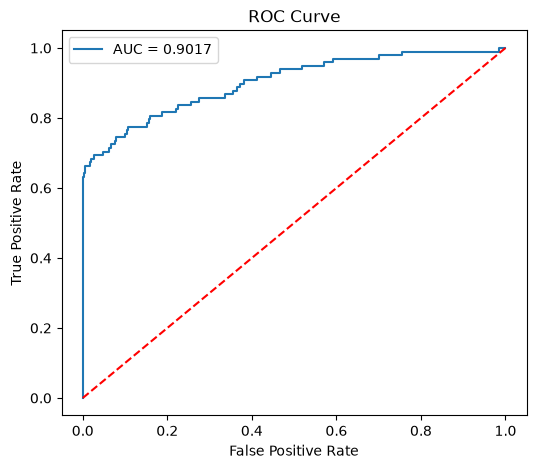

In [31]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## ROC Curve Interpretation

The ROC (Receiver Operating Characteristic) curve illustrates the trade-off between the True Positive Rate (Recall) and the False Positive Rate at different classification thresholds.

The Logistic Regression model achieved an ROC-AUC score of **0.9017**, indicating a strong ability to distinguish between fraudulent and legitimate transactions.

An AUC value close to 1 represents excellent classification performance, whereas an AUC of 0.5 indicates random guessing. Therefore, the obtained AUC score suggests that the model performs well for fraud detection.

# Conclusion

A Logistic Regression model was developed to detect fraudulent credit card transactions.

The dataset was highly imbalanced, making evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC more informative than accuracy alone.

### Model Performance

- Accuracy: Nearly 100%
- Precision (Fraud): 0.62
- Recall (Fraud): 0.56
- F1-score (Fraud): 0.59
- ROC-AUC Score: 0.9017

The model classified legitimate transactions with very high accuracy while successfully detecting a significant number of fraudulent transactions. However, some fraudulent transactions were still missed (False Negatives), indicating room for improvement.

Overall, Logistic Regression serves as a strong baseline model for credit card fraud detection. More advanced techniques such as Random Forest, XGBoost, or class balancing methods (e.g., SMOTE) may further improve fraud detection performance.

## Future Scope

- Apply SMOTE or other resampling techniques to address class imbalance.
- Train advanced models such as Random Forest, XGBoost, or LightGBM.
- Perform hyperparameter tuning using GridSearchCV or RandomizedSearchCV.
- Deploy the trained model as a real-time fraud detection web application using Flask or Streamlit.